# Maya v2 — continuous streaming with in-flight MFC commands

This notebook uses `maya_v2.py`, which keeps one persistent USB Serial
connection to the Teensy and runs the sensor-packet reader in a background
thread. That lets us switch MFCs *while* the sensor stream is running,
without stopping and restarting the stream.

**Safe to call during streaming:** `MFCControl.set_flow`, `MFCControl.blink`,
`PCF8575Control_.send_state` (binary command, no USB text response).

**NOT safe during streaming:** `MFCControl.read_registers` — the firmware
writes `DATA:...` on the USB Serial and would corrupt the binary packet
stream. `maya_v2.MFCControl` refuses it while streaming.

In [2]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt

from maya_v2 import SerialCommunication, PCF8575Control_, MFCControl

In [3]:
# --- Serial / hardware configuration ---
PORT = "/dev/ttyACM0"   # adjust to your Teensy's serial port
BAUDRATE = 115200
FREQUENCY = 1           # sampling frequency (Hz) set on the Teensy

# DAC configuration
dac1_value = 800
dac2_value = 200

# PCF8575 configuration
PCF_flags = [True] * 16
PCF_frequencies = ["0"] * 16

sensor_id = ["U1-TGS2602", "U2-TGS2610-D00", "U3-SP3S-AQ2", "U4-GSBT11-DXX",
             "U8-TGS2600", "U9-TGS2603", "U10-TGS2630", "U13-TGS2612-D00",
             "U14-TGS2620", "U15-MG-812", "U16-TGS-3830", "U19-TGS1820",
             "U20-TGS2611-E00", "U21-TGS2616-C00", "U22-WSP2110", "U25-TGS-3870",
             "U7-BME680"]

# Responding-sensor mask copied from "Sensor signal plots + adding noise.ipynb"
# (variable `responding_sens`):
#   responding_sens = [0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0]
responding_sens = [0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0]
ACTIVE_SENSOR_INDICES = [i for i, v in enumerate(responding_sens) if v == 1]
#  1  -> U2-TGS2610-D00
#  4  -> U8-TGS2600
#  6  -> U10-TGS2630
#  7  -> U13-TGS2612-D00
#  8  -> U14-TGS2620
# 10  -> U16-TGS-3830
# 11  -> U19-TGS1820
# 12  -> U20-TGS2611-E00

In [ ]:
# Open ONE persistent serial connection. All commands and the streaming
# reader share this same `SerialCommunication` object.
serial_comm = SerialCommunication(PORT, BAUDRATE)

# Push initial DAC + sampling-frequency config to the Teensy
serial_comm.send_message(f"{dac1_value},{dac2_value},{FREQUENCY}")

# Initial PCF8575 state (all sensors ON)
PCF_control = PCF8575Control_(serial_comm, flags=PCF_flags, frequencies=PCF_frequencies)
PCF_control.send_state()

# Zero all MFCs before we begin
MFC_control = MFCControl(serial_comm)
for addr in (1, 2, 3):
    MFC_control.set_flow(addr, 0.0)

## Sanity-check experiment — 30 s sequence

Quick test to confirm that MFC commands sent during a live stream are honoured and show up in the sensor trace at the right times.

Timeline (wall-clock relative to `start_streaming`):

- `t =  0 s` — streaming starts, all MFCs closed
- `t = 10 s` — MFC 2 opened to flow = 1.0
- `t = 20 s` — MFC 2 closed
- `t = 30 s` — streaming stops

Every MFC event is logged with a timestamp in `times_seq` so the sequence can be aligned with the sensor trace afterwards.

In [38]:
# --- 30 s sanity-check experiment (no CSV, in-memory only) ---
#   t =  0 s : streaming starts, all MFCs closed
#   t = 10 s : MFC 2 -> flow 1.0
#   t = 20 s : MFC 2 -> flow 0.0
#   t = 30 s : streaming stops

# Make sure everything is closed before we start
for addr in (1, 2, 3):
    MFC_control.set_flow(addr, 0.0)

times_seq = []   # (unix_t, asctime, event, mfc_addr, flow)

# Stream to memory only; buffer big enough for the whole run.
serial_comm.start_streaming(save_csv=False, buffer_size=10_000)
try:
    t0 = time.time()
    times_seq.append((time.time(), time.asctime(), "stream_start", 0, 0.0))

    time.sleep(10.0 - (time.time() - t0))
    MFC_control.set_flow(2, 1.0)
    times_seq.append((time.time(), time.asctime(), "on", 2, 1.0))

    time.sleep(20.0 - (time.time() - t0))
    MFC_control.set_flow(2, 0.0)
    times_seq.append((time.time(), time.asctime(), "off", 2, 0.0))

    time.sleep(30.0 - (time.time() - t0))
    times_seq.append((time.time(), time.asctime(), "stream_end", 0, 0.0))
    print(f"Experiment wall-time: {time.time() - t0:.2f} s")
finally:
    packets = serial_comm.get_latest_packets()
    serial_comm.stop_streaming()

# --- Parse in-memory packets and plot ---
sensor_data = []
times = []
for row in packets:
    times.append(row[0])
    values = []
    for i in range(17):
        b1 = int(row[2 * i + 1]); b2 = int(row[2 * i + 2])
        values.append(int.from_bytes([b1, b2], byteorder="little"))
    sensor_data.append(values)
sensor_data = np.array(sensor_data)
print(f"Captured {sensor_data.shape[0]} packets × {sensor_data.shape[1]} channels")

if len(sensor_data) > 0:
    fig, ax = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
    for i in range(4):
        for j in range(4):
            idx = i * 4 + j
            ax[i, j].plot(sensor_data[:, idx])
            ax[i, j].set_title(sensor_id[idx], fontsize=9)
            ax[i, j].set_xticks([])
    fig.suptitle("Sanity check — MFC2 open at t=10s, closed at t=20s")
    plt.tight_layout()
    plt.show()

NameError: name 'MFC_control' is not defined

## Main experiment — 32 min recording with MFC2/3 mixture + MFC1 pulses (v2)

Total recording: **32 min = 1920 s**.

**MFC 2 & 3 mixture** — every 10 s the (flow2, flow3) setpoint is drawn uniformly at random from:

```
(0.00, 0.50), (0.10, 0.40), (0.20, 0.30), (0.40, 0.10)
```

Consecutive periods may repeat the same configuration (independent sampling). 1920 / 10 = **192 periods**.

**MFC 1 pulses** — 30 pulses, one per minute, **all of duration 5 s**:

- 0 – 60 s (1 min): baseline, MFC1 closed
- 60 – 1860 s (30 min): one pulse at the start of each minute (MFC1 = 1.0 for 5 s, then 0.0)
- 1860 – 1920 s (1 min): buffer after the last pulse

All event timestamps (config changes, pulse on/off) are recorded in `times_seq` and pickled alongside the CSV.

In [4]:
import random

# --- Experiment parameters (v2) ---
T_TOTAL        = 32 * 60     # 1920 s
T_BASELINE     = 1 * 60      # 60 s  -- no MFC1 pulses before this
T_BUFFER       = 1 * 60      # 60 s  -- no MFC1 pulses after the last one
CONFIG_PERIOD  = 10          # s between MFC2/MFC3 setpoint changes
PULSE_INTERVAL = 60          # s between successive MFC1 pulse starts
PULSE_OFFSET   = 2           # s offset of each pulse within its minute,
                             # so pulse edges don't coincide with config changes
PULSE_DURATION = 5           # s -- single fixed duration for every pulse
N_PULSES       = 30          # total number of MFC1 pulses

CONFIGS = [(0.00, 0.50), (0.10, 0.40), (0.20, 0.30), (0.40, 0.10)]

filename = "data/ced_30_5.csv"

In [ ]:

# --- Build the schedule ---
# MFC2/3 config sequence: one config per CONFIG_PERIOD seconds, sampled independently.
n_periods = T_TOTAL // CONFIG_PERIOD
config_sequence = [random.choice(CONFIGS) for _ in range(n_periods)]

# MFC1 pulses: all of the same duration.
pulse_durations = [PULSE_DURATION] * N_PULSES

assert len(pulse_durations) == N_PULSES
n_pulse_slots = (T_TOTAL - T_BASELINE - T_BUFFER) // PULSE_INTERVAL
assert n_pulse_slots == N_PULSES, (
    f"Expected {N_PULSES} pulse slots, got {n_pulse_slots}")

# Build (t, action, payload) events.
events = []
for i, cfg in enumerate(config_sequence):
    events.append((i * CONFIG_PERIOD, "config", cfg))
for k_p, dur in enumerate(pulse_durations):
    t_on  = T_BASELINE + k_p * PULSE_INTERVAL + PULSE_OFFSET
    t_off = t_on + dur
    events.append((t_on,  "pulse_on",  dur))
    events.append((t_off, "pulse_off", dur))
events.sort(key=lambda e: e[0])

print(f"Periods: {n_periods}, pulses: {len(pulse_durations)} "
      f"(all {PULSE_DURATION}s), total duration: {T_TOTAL}s")

# --- Run the experiment ---
if os.path.exists(filename):
    os.remove(filename)
os.makedirs(os.path.dirname(filename), exist_ok=True)

# Make sure all MFCs are closed before starting.
for addr in (1, 2, 3):
    MFC_control.set_flow(addr, 0.0)

times_seq = []  # (unix_t, t_target_s, action, payload)

serial_comm.start_streaming(filename=filename, save_csv=True)
try:
    t0 = time.time()
    times_seq.append((time.time(), 0.0, "stream_start", None))

    for t_target, action, payload in events:
        now = time.time() - t0
        sleep_for = t_target - now
        if sleep_for > 0:
            time.sleep(sleep_for)

        if action == "config":
            f2, f3 = payload
            MFC_control.set_flow(2, f2)
            MFC_control.set_flow(3, f3)
        elif action == "pulse_on":
            MFC_control.set_flow(1, 1.0)
        elif action == "pulse_off":
            MFC_control.set_flow(1, 0.0)

        times_seq.append((time.time(), float(t_target), action, payload))

    # Tail: run out the clock to the full T_TOTAL.
    remaining = T_TOTAL - (time.time() - t0)
    if remaining > 0:
        time.sleep(remaining)

    times_seq.append((time.time(), float(T_TOTAL), "stream_end", None))
    print(f"Experiment wall-time: {time.time() - t0:.2f} s "
          f"(target {T_TOTAL} s)")
finally:
    # Always close MFC1 and stop the stream, even on interrupt.
    try:
        MFC_control.set_flow(1, 0.0)
    except Exception:
        pass
    serial_comm.stop_streaming()

# Strip the .csv suffix so the sequence pickle is e.g. "data/ced_30_5_sequence.pkl"
# rather than "data/ced_30_5.csv_sequence.pkl".
seq_filename = (filename[:-4] if filename.endswith(".csv") else filename) + "_sequence.pkl"
with open(seq_filename, "wb") as f:
    pickle.dump(
        {
            "events": times_seq,
            "config_sequence": config_sequence,
            "pulse_durations": pulse_durations,
            "params": {
                "T_TOTAL": T_TOTAL,
                "T_BASELINE": T_BASELINE,
                "T_BUFFER": T_BUFFER,
                "CONFIG_PERIOD": CONFIG_PERIOD,
                "PULSE_INTERVAL": PULSE_INTERVAL,
                "PULSE_OFFSET": PULSE_OFFSET,
                "PULSE_DURATION": PULSE_DURATION,
                "N_PULSES": N_PULSES,
                "CONFIGS": CONFIGS,
            },
        },
        f,
    )
print(f"Sequence log saved to {seq_filename}")

## Cleanup

In [ ]:
# Zero the MFCs and close the serial port when you're done.
for addr in (1, 2, 3):
    MFC_control.set_flow(addr, 0.0)
serial_comm.close()

## Main experiment — load and plot sensor traces

Reads the CSV written by the main experiment cell above. Pulse windows (MFC1 on) are shaded on each sensor trace so the pulse response is visible at a glance.

In [5]:
import csv
from datetime import datetime

# Re-load the main experiment's CSV and sequence log.
seq_filename = (filename[:-4] if filename.endswith(".csv") else filename) + "_sequence.pkl"
with open(seq_filename, "rb") as f:
    seq = pickle.load(f)
events = seq["events"]

sensor_data = []
times = []
with open(filename, "r") as f:
    reader = csv.reader(f)
    for row in reader:
        if not row or row[0] == "Timestamp":
            continue
        times.append(row[0])
        values = []
        for i in range(17):
            b1 = int(row[2 * i + 1]); b2 = int(row[2 * i + 2])
            values.append(int.from_bytes([b1, b2], byteorder="little"))
        sensor_data.append(values)
sensor_data = np.array(sensor_data)
print(f"Loaded {sensor_data.shape[0]} packets × {sensor_data.shape[1]} channels")

# Convert packet timestamps to seconds since stream start.
t_stream_start = events[0][0]  # unix_t of stream_start event
t_seconds = np.array([
    (datetime.strptime(ts, "%Y-%m-%d %H:%M:%S.%f").timestamp() - t_stream_start)
    for ts in times
])

# Extract pulse on/off windows for shading.
pulse_windows = []
t_on = None
for unix_t, t_target, action, payload in events:
    t_rel = unix_t - t_stream_start
    if action == "pulse_on":
        t_on = t_rel
    elif action == "pulse_off" and t_on is not None:
        pulse_windows.append((t_on, t_rel, payload))
        t_on = None

Loaded 1919 packets × 17 channels


## Expand & sparsify + Hebbian binary readout

Pipeline (mirrors `gridsearch_single_framewise_mixed.py` and `gridsearch_binary_framewise_mixed.py`):

1. **Reduce** to active sensors only (`ACTIVE_SENSOR_INDICES`, 8 channels).
2. **Expansion** `∂¹+∂² + 56R + 56D` — concatenate raw, 1st and 2nd backward differences, all 56 ordered ratios `s_i / s_j` and all 56 ordered differences `s_i - s_j` (`n_sensors * (n_sensors-1) = 8*7 = 56`).
3. **Random projection** `W_hd ∼ Bernoulli(p_hd)` of shape `(n_hd, n_dense)`.
4. **Top-k sparsification** — binary mask, 1 at the top-`k` projected components per frame, 0 elsewhere.
5. **Hebbian readout — 2 neurons.** Each frame, every active HD component flips the matching neuron's readout synapse to 1 with probability `p`.
   - **Neuron 0 (MFC1 ON)** learns when MFC1 is open — the last 4 s of each of the first `N_LEARN_PULSES` pulses (`LEARN_OFFSET = 1 s` after onset).
   - **Neuron 1 (MFC1 OFF)** learns when MFC1 is closed — the gaps between (and before) those pulses, with a 1 s offset after each falling edge to skip the post-pulse transient.

   Weights freeze once the last learning pulse closes; inference (both neurons) runs end-to-end on the full sequence.

**Parameters:** `n_hd=10000`, `n_out=2`, `k=500`, `p=0.01`, `p_hd=0.025`, `LEARN_OFFSET=1.0 s`, `N_LEARN_PULSES=15`.

In [29]:

def plot_traces_and_readout(t_lo, t_hi, title,
                            figsize=(10, 5),
                            with_pulse_aligned=False):
    """Stacked sensor traces (top) + output neuron z_out (middle).

    The middle row plots both readout neurons:
      - z_out[:, 0]  -> "MFC1 ON"  (red,  C3)
      - z_out[:, 1]  -> "MFC1 OFF" (blue, C0)

    If ``with_pulse_aligned`` is True, a third row with a single subplot is
    added, showing both neurons' z_out scattered against time since pulse
    onset for every MFC1 pulse.

    Restricted to t in [t_lo, t_hi] (in seconds since stream start) for the
    top two rows. The pulse-aligned row uses all pulses in the recording.
    """
    if len(sensor_data) == 0:
        return

    active_idx   = ACTIVE_SENSOR_INDICES
    active_names = [sensor_id[i] for i in active_idx]
    data_T = sensor_data[:, active_idx].T  # (n_active, n_packets)

    if with_pulse_aligned:
        fig = plt.figure(figsize=figsize)
        gs  = fig.add_gridspec(
            3, 1,
            height_ratios=[1, 1, 1],
            hspace=0.4,
        )
        ax_top = fig.add_subplot(gs[0, 0])
        ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)
        ax_pul = fig.add_subplot(gs[2, 0])
    else:
        fig, (ax_top, ax_bot) = plt.subplots(
            2, 1, figsize=figsize, sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )
        ax_pul = None

    # --- Top: stacked sensor traces (original Maya style) ---
    for i, row in enumerate(data_T):
        baseline = np.mean(row[:10])
        signal = (np.array(row) - baseline) / 65536.
        if i == 0:
            ax_top.plot(t_seconds, signal, lw=0.6)
        else:
            ax_top.plot(t_seconds, signal * 6 + 2 * i, lw=0.6)

    y_lo, y_hi = -1, 2 * len(data_T) + 1
    for t_on, t_off, dur in pulse_windows:
        if t_off >= t_lo and t_on <= t_hi:
            ax_top.fill([t_on, t_on, t_off, t_off],
                        [y_lo, y_hi, y_hi, y_lo],
                        color="gray", alpha=0.25)
    ax_top.set_yticks(2 * np.arange(len(data_T)), labels=active_names)
    ax_top.spines[["top", "right", "left"]].set_visible(False)
    ax_top.tick_params(left=False, labelleft=True)
    ax_top.set_ylim([y_lo, y_hi])

    # --- Middle: output neuron activity (both neurons) ---
    ax_bot.plot(t_seconds, z_out[:, 0], lw=0.7, color="C3", label="neuron 0 — MFC1 ON")
    ax_bot.plot(t_seconds, z_out[:, 1], lw=0.7, color="C0", label="neuron 1 — MFC1 OFF")
    ax_bot.axhline(k, color="0.6", lw=0.5, linestyle=":")
    if t_lo <= t_freeze <= t_hi:
        ax_bot.axvline(t_freeze, color="k", lw=0.7, linestyle="--",
                       label=f"freeze (t={t_freeze:.0f}s)")
    ax_bot.legend(loc="lower right", fontsize=8, frameon=False, ncol=3)
    for t_on, t_off, dur in pulse_windows:
        if t_off >= t_lo and t_on <= t_hi:
            ax_bot.axvspan(t_on, t_off, color="gray", alpha=0.25)
    ax_bot.set_xlabel("t (s)")
    ax_bot.set_ylabel(f"z_out  (max {k})")
    ax_bot.spines[["top", "right"]].set_visible(False)
    ax_bot.set_xlim([t_lo, t_hi])

    # --- Bottom: pulse-aligned readout response (single duration in v2) ---
    if with_pulse_aligned:
        onsets = [t_on for t_on, _, _ in pulse_windows]
        for t_on in onsets:
            mask = (t_seconds >= t_on) & (t_seconds <= t_on + PULSE_T_WINDOW)
            rel_t = t_seconds[mask] - t_on
            ax_pul.scatter(rel_t, z_out[mask, 0], s=8, alpha=0.5,
                           edgecolors="none", color="C3")
            ax_pul.scatter(rel_t, z_out[mask, 1], s=8, alpha=0.5,
                           edgecolors="none", color="C0")
        # Legend handles for the two neurons (one entry each, full-opacity).
        ax_pul.scatter([], [], s=20, color="C3", label="neuron 0 — MFC1 ON")
        ax_pul.scatter([], [], s=20, color="C0", label="neuron 1 — MFC1 OFF")
        ax_pul.legend(loc="upper right", fontsize=8, frameon=False)
        ax_pul.axhline(k, color="0.6", lw=0.5, linestyle=":")
        ax_pul.axvspan(0, PULSE_DURATION, color="gray", alpha=0.2, lw=0)
        ax_pul.set_xlim(0, PULSE_T_WINDOW)
        ax_pul.set_xlabel("time since pulse onset (s)")
        ax_pul.set_ylabel(r"$z_{out}$" + f"  (max {k})")
        ax_pul.set_title(f"{PULSE_DURATION} s pulses (n = {len(onsets)})")
        ax_pul.spines[["top", "right"]].set_visible(False)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# --- Expansion (∂¹+∂² + 56R + 56D) ---
def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1) ** kk * comb(n, kk) for kk in range(n + 1)])
    raw = np.convolve(y, coeffs, mode="valid") / h ** n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data
        )
        derivs.append(d)
    return np.hstack([data] + derivs)

In [33]:
from math import comb

# --- Network parameters ---
n_hd  = 10000
n_out = 2          # neuron 0 -> MFC1 ON,  neuron 1 -> MFC1 OFF
k     = 500
p     = 1.    # output synapse flip probability per active HD component
p_hd  = 0.025   # density of the random HD projection matrix

# Learning rule (v2): pulse-gated, restricted to the first N_LEARN_PULSES.
LEARN_OFFSET    = 1.0   # s into each pulse before learning turns on,
                        # also s after each falling edge before OFF learning resumes
N_LEARN_PULSES  = 15    # learn on the first N_LEARN_PULSES pulses, then freeze

# --- Reduce to active sensors only ---
sensor_data_active = sensor_data[:, ACTIVE_SENSOR_INDICES].astype(float)
n_sensors = sensor_data_active.shape[1]
h = float(np.median(np.diff(t_seconds)))
print(f"Active sensors: {n_sensors}, h = {h:.3f} s")


all_pairs = [(i, j) for i in range(n_sensors)
                    for j in range(n_sensors) if i != j]   # 8*7 = 56
deriv  = expand_with_derivatives(sensor_data_active, h, max_order=2)
ratios = np.column_stack([sensor_data_active[:, i] / (sensor_data_active[:, j] + 1e-8)
                          for i, j in all_pairs])
diffs  = np.column_stack([sensor_data_active[:, i] - sensor_data_active[:, j]
                          for i, j in all_pairs])
expanded = np.hstack([deriv, ratios, diffs])
n_dense = expanded.shape[1]
print(f"Expanded feature dim: {n_dense}  "
      f"(deriv: {deriv.shape[1]}, ratios: {ratios.shape[1]}, diffs: {diffs.shape[1]})")


# --- Random HD projection + top-k sparsification ---
rng = np.random.default_rng(42)
W_hd = rng.binomial(n=1, p=p_hd, size=(n_hd, n_dense)).astype(np.float32)
x_hd = expanded @ W_hd.T
ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
z_hd = (ranks < k).astype(np.float32)


# --- Pulse-gated learning windows for the first N_LEARN_PULSES pulses ---
learn_pulses = pulse_windows[:N_LEARN_PULSES]

# ON windows: last 4 s of each learning pulse.
learn_windows_on = [(t_on + LEARN_OFFSET, t_off) for t_on, t_off, _ in learn_pulses]

# OFF windows: gaps between (and before) learning pulses, with a LEARN_OFFSET
# skip after each falling edge so the post-pulse transient doesn't leak in.
learn_windows_off = []
prev_end = 0.0   # start of recording
for t_on, t_off, _ in learn_pulses:
    lo = prev_end + (LEARN_OFFSET if prev_end > 0 else 0.0)
    hi = t_on
    if hi > lo:
        learn_windows_off.append((lo, hi))
    prev_end = t_off

learn_mask_on  = np.zeros(len(t_seconds), dtype=bool)
learn_mask_off = np.zeros(len(t_seconds), dtype=bool)
for w_lo, w_hi in learn_windows_on:
    learn_mask_on  |= (t_seconds >= w_lo) & (t_seconds <= w_hi)
for w_lo, w_hi in learn_windows_off:
    learn_mask_off |= (t_seconds >= w_lo) & (t_seconds <= w_hi)

# Weights are frozen after the last learning pulse closes.
if learn_pulses:
    t_freeze = learn_pulses[-1][1]
    print(f"Learning on {len(learn_pulses)} pulses "
          f"(LEARN_OFFSET {LEARN_OFFSET:.1f}s); freeze at t = {t_freeze:.2f} s")
    print(f"Learning frames — ON : {int(learn_mask_on.sum())} / {len(t_seconds)}")
    print(f"Learning frames — OFF: {int(learn_mask_off.sum())} / {len(t_seconds)}")
else:
    t_freeze = float(t_seconds[-1])
    print("No pulses available for learning; W_out stays zero.")


# --- Online Hebbian update only during the learning windows; then frozen
# inference is run end-to-end on the full sequence. Each frame, every
# active HD component flips its readout synapse to 1 with probability p
# (matches gridsearch_single_framewise_mixed.py). ---
W_out = np.zeros((n_out, n_hd), dtype=np.float32)
z_out = np.zeros((len(t_seconds), n_out), dtype=np.float32)
for i in range(len(t_seconds)):
    active = np.flatnonzero(z_hd[i])
    if learn_mask_on[i]:
        to_flip = active[rng.random(active.size) < p]
        W_out[0, to_flip] = 1.0
    if learn_mask_off[i]:
        to_flip = active[rng.random(active.size) < p]
        W_out[1, to_flip] = 1.0
    z_out[i] = z_hd[i] @ W_out.T

print(f"Final W_out density — neuron 0 (ON):  {W_out[0].mean():.3f} "
      f"({int(W_out[0].sum())}/{n_hd} synapses set)")
print(f"Final W_out density — neuron 1 (OFF): {W_out[1].mean():.3f} "
      f"({int(W_out[1].sum())}/{n_hd} synapses set)")
print(f"z_out[:,0] (ON)  range: [{z_out[:,0].min():.0f}, {z_out[:,0].max():.0f}]   (k = {k})")
print(f"z_out[:,1] (OFF) range: [{z_out[:,1].min():.0f}, {z_out[:,1].max():.0f}]   (k = {k})")

Active sensors: 8, h = 1.000 s
Expanded feature dim: 136  (deriv: 24, ratios: 56, diffs: 56)
Learning on 15 pulses (LEARN_OFFSET 1.0s); freeze at t = 907.00 s
Learning frames — ON : 60 / 1919
Learning frames — OFF: 817 / 1919
Final W_out density — neuron 0 (ON):  0.065 (655/10000 synapses set)
Final W_out density — neuron 1 (OFF): 0.084 (841/10000 synapses set)
z_out[:,0] (ON)  range: [0, 500]   (k = 500)
z_out[:,1] (OFF) range: [444, 500]   (k = 500)


/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_87721/508713095.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


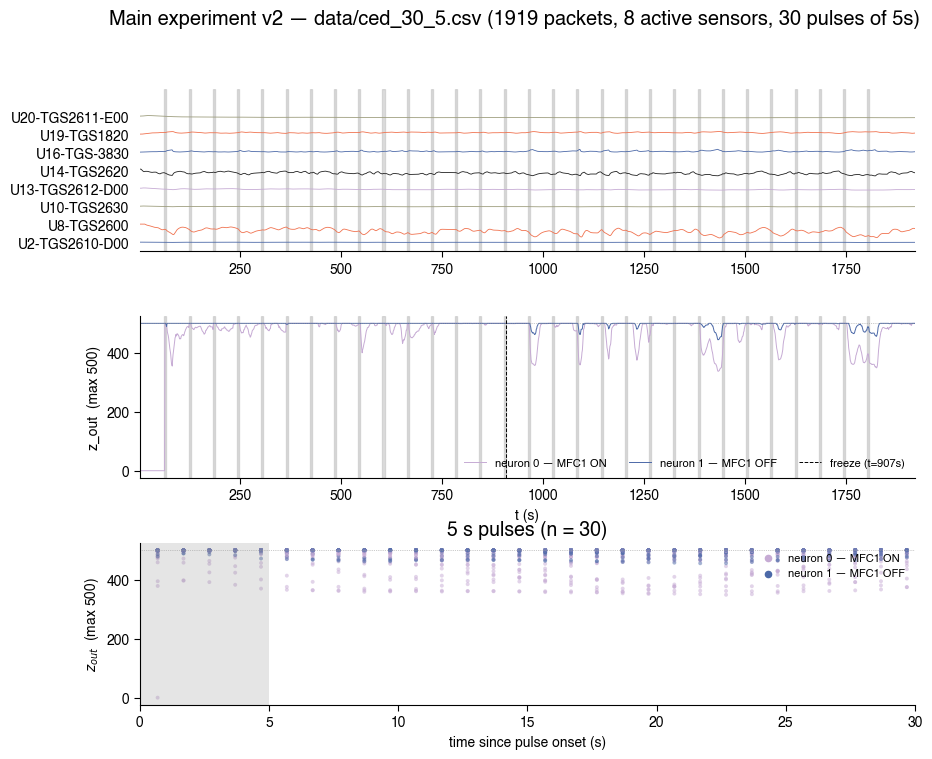

In [34]:
PULSE_COLOR    = "C0"
PULSE_T_WINDOW = 30.0     # s after pulse onset for the pulse-aligned plot


# Full main-experiment view + pulse-aligned readout response.
plot_traces_and_readout(
    t_lo=float(t_seconds[0]),
    t_hi=float(t_seconds[-1]),
    title=(f"Main experiment v2 — {filename} "
           f"({sensor_data.shape[0]} packets, "
           f"{len(ACTIVE_SENSOR_INDICES)} active sensors, "
           f"{len(pulse_windows)} pulses of {PULSE_DURATION}s)"),
    figsize=(10, 8),
    with_pulse_aligned=True,
)

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_87721/508713095.py:100: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Helvetica.
  plt.tight_layout()
/Users/ton/.venv/phd_2025/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


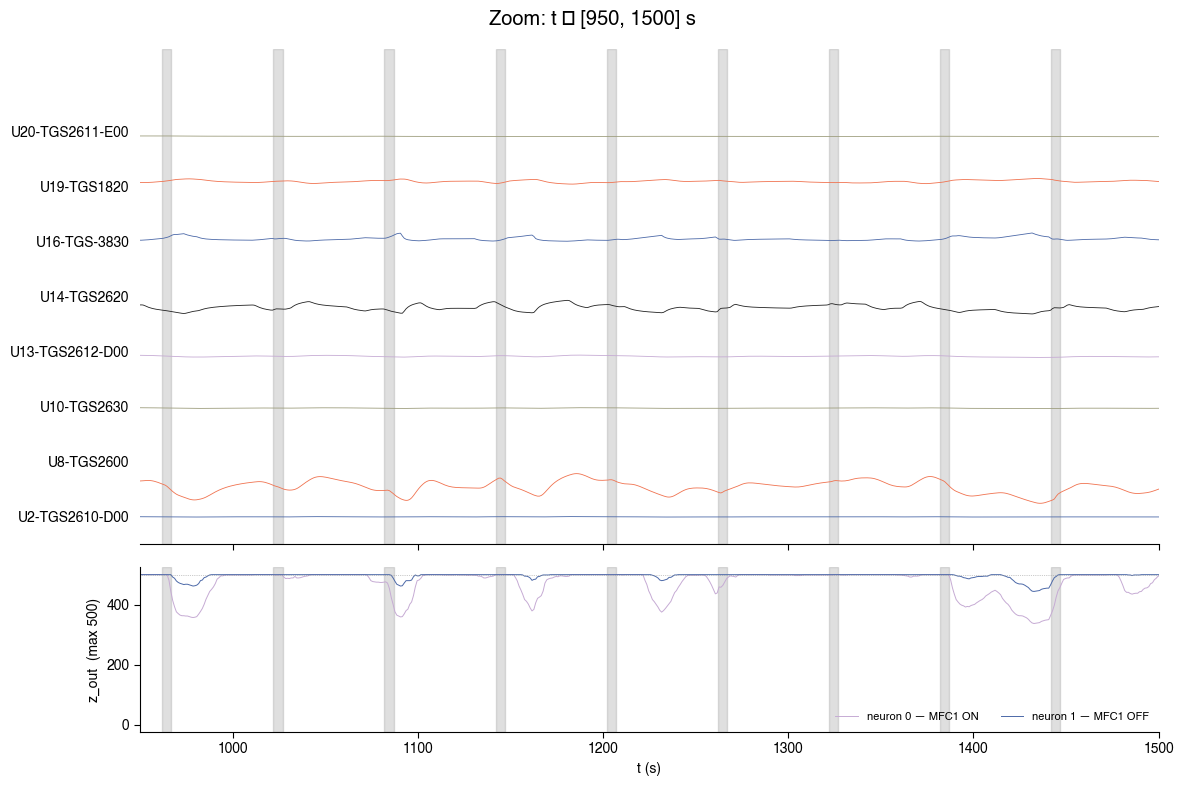

In [35]:
# Zoomed-in view:
t_lo = 950
t_hi = 1500
plot_traces_and_readout(
    t_lo=t_lo,
    t_hi=t_hi,
    title=f"Zoom: t ∈ [{t_lo}, {t_hi}] s",
    figsize=(12, 8),
)